# Heart Disease Detection Using Machine Learning

## Introduction

This notebook presents the development of a machine learning model for detecting the presence of heart disease using a publicly available cardiovascular dataset.

The workflow includes data loading, preprocessing, exploratory data analysis, model development, evaluation and selection of the final deployment model. The selected model is later integrated into a Flask web application as one of the prediction modules within the overall Heart Disease Prediction System.

In [6]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
# ============================================================
# Load Dataset
# ============================================================

heart = pd.read_csv("/content/heart.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", heart.shape)

heart.head()


Dataset loaded successfully.
Dataset shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# 1. Dataset Overview

This notebook develops a binary heart disease detection model using the Heart Disease dataset. The original target variable contains values from 0 to 4. For this project, value 0 represents no heart disease, while values 1 to 4 are grouped into a single positive class representing the presence of heart disease.

In [8]:
# ============================================================
# Inspect the Heart Disease Dataset
# ============================================================

print("Dataset shape:", heart.shape)

print("\nColumns:")
print(heart.columns.tolist())

print("\nData types:")
print(heart.dtypes)

print("\nMissing values:")
print(heart.isnull().sum())

print("\nOriginal target distribution:")
print(heart["num"].value_counts().sort_index())


Dataset shape: (920, 16)

Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Data types:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Missing values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Original target distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


# 2. Data Preprocessing

The identifier column is removed because it does not contain predictive information. The `ca` and `thal` columns are excluded because more than half of their records are missing. Remaining numerical values are imputed using the median, while categorical values are imputed using the mode. Categorical variables are then converted into numerical labels.

In [9]:
# ============================================================
# Data Cleaning
# ============================================================

from sklearn.preprocessing import LabelEncoder

heart_clean = heart.copy()

# Remove identifier and highly incomplete columns
heart_clean = heart_clean.drop(columns=["id", "ca", "thal"])

# Fill numerical missing values with the median
numeric_columns = heart_clean.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numeric_columns:
    heart_clean[column] = heart_clean[column].fillna(
        heart_clean[column].median()
    )

# Fill categorical missing values with the mode
categorical_columns = heart_clean.select_dtypes(
    include=["object", "string"]
).columns

for column in categorical_columns:
    heart_clean[column] = heart_clean[column].fillna(
        heart_clean[column].mode()[0]
    )

print("Total missing values after cleaning:")
print(heart_clean.isnull().sum().sum())

Total missing values after cleaning:
0


/tmp/ipykernel_5846/1011579469.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heart_clean[column] = heart_clean[column].fillna(


In [10]:
# ============================================================
# Encode Categorical Variables
# ============================================================

heart_encoded = heart_clean.copy()
encoders = {}

categorical_columns = heart_encoded.select_dtypes(
    include=["object", "string"]
).columns

for column in categorical_columns:
    encoder = LabelEncoder()
    heart_encoded[column] = encoder.fit_transform(
        heart_encoded[column].astype(str)
    )
    encoders[column] = encoder

print("Encoding completed.")

print("\nEncoded feature columns:")
print(heart_encoded.columns.tolist())

print("\nData types after encoding:")
print(heart_encoded.dtypes)

Encoding completed.

Encoded feature columns:
['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'num']

Data types after encoding:
age           int64
sex           int64
dataset       int64
cp            int64
trestbps    float64
chol        float64
fbs            bool
restecg       int64
thalch      float64
exang          bool
oldpeak     float64
slope         int64
num           int64
dtype: object


## Binary Target Conversion

The original target records heart disease severity using values from 0 to 4. To support binary classification and match the application design, values greater than 0 are converted to class 1.

In [11]:
# ============================================================
# Feature Matrix and Binary Target
# ============================================================

X_heart = heart_encoded.drop("num", axis=1)
y_heart = (heart_encoded["num"] > 0).astype(int)

print("Feature matrix shape:", X_heart.shape)
print("Target shape:", y_heart.shape)

print("\nBinary target distribution:")
print(y_heart.value_counts())

Feature matrix shape: (920, 12)
Target shape: (920,)

Binary target distribution:
num
1    509
0    411
Name: count, dtype: int64


# 3. Model Development and Evaluation

The cleaned dataset was divided into training and testing sets. Logistic Regression, Random Forest and XGBoost were trained using the same split so their performance could be compared consistently.

In [12]:
# ============================================================
# Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(
    X_heart,
    y_heart,
    test_size=0.20,
    random_state=42,
    stratify=y_heart
)

print("Training set:", X_train_heart.shape)
print("Testing set :", X_test_heart.shape)

Training set: (736, 12)
Testing set : (184, 12)


In [13]:
# ============================================================
# Feature Scaling for Logistic Regression
# ============================================================

scaler_heart = StandardScaler()

X_train_heart_scaled = scaler_heart.fit_transform(X_train_heart)
X_test_heart_scaled = scaler_heart.transform(X_test_heart)

print("Feature scaling completed.")

Feature scaling completed.


In [14]:
# ============================================================
# Train Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

heart_logistic = LogisticRegression(
    random_state=42,
    max_iter=1000
)

heart_logistic.fit(
    X_train_heart_scaled,
    y_train_heart
)

heart_logistic_pred = heart_logistic.predict(
    X_test_heart_scaled
)

print("Logistic Regression trained.")

Logistic Regression trained.


In [15]:
# ============================================================
# Train Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

heart_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

heart_rf.fit(
    X_train_heart,
    y_train_heart
)

heart_rf_pred = heart_rf.predict(X_test_heart)

print("Random Forest trained.")

Random Forest trained.


In [16]:
# ============================================================
# Train XGBoost
# ============================================================

from xgboost import XGBClassifier

heart_xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

heart_xgb.fit(
    X_train_heart,
    y_train_heart
)

heart_xgb_pred = heart_xgb.predict(X_test_heart)

print("XGBoost trained.")

XGBoost trained.


In [17]:
# ============================================================
# Model Comparison
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

heart_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test_heart, heart_logistic_pred),
        accuracy_score(y_test_heart, heart_rf_pred),
        accuracy_score(y_test_heart, heart_xgb_pred)
    ],
    "Precision": [
        precision_score(y_test_heart, heart_logistic_pred),
        precision_score(y_test_heart, heart_rf_pred),
        precision_score(y_test_heart, heart_xgb_pred)
    ],
    "Recall": [
        recall_score(y_test_heart, heart_logistic_pred),
        recall_score(y_test_heart, heart_rf_pred),
        recall_score(y_test_heart, heart_xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test_heart, heart_logistic_pred),
        f1_score(y_test_heart, heart_rf_pred),
        f1_score(y_test_heart, heart_xgb_pred)
    ]
}).round(4)

heart_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8315,0.8381,0.8627,0.8502
1,Random Forest,0.8043,0.8056,0.8529,0.8286
2,XGBoost,0.8370,0.8462,0.8627,0.8544


# 4. Final Model Evaluation

XGBoost achieved the strongest overall performance among the evaluated models. The final model is assessed using a classification report and confusion matrix before being saved for Flask integration.

In [18]:
# ============================================================
# XGBoost Detailed Evaluation
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

print("XGBoost Classification Report\n")
print(classification_report(y_test_heart, heart_xgb_pred))

heart_xgb_cm = confusion_matrix(
    y_test_heart,
    heart_xgb_pred
)

print("\nConfusion Matrix:")
print(heart_xgb_cm)

XGBoost Classification Report

              precision    recall  f1-score   support

           0       0.82      0.80      0.81        82
           1       0.85      0.86      0.85       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184


Confusion Matrix:
[[66 16]
 [14 88]]


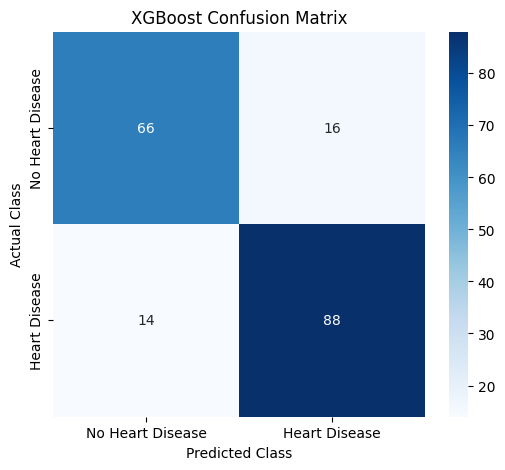

In [19]:
# ============================================================
# XGBoost Confusion Matrix
# ============================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    heart_xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [20]:
# ============================================================
# Save Heart Disease Deployment Model
# ============================================================

joblib.dump(
    heart_xgb,
    "heart_model.pkl"
)

print("Heart Disease XGBoost model saved successfully.")

Heart Disease XGBoost model saved successfully.


# 5. Conclusion

This notebook developed a binary heart disease detection model using the Heart Disease dataset. The original multi-class target was converted into a binary outcome representing the absence or presence of heart disease.

Logistic Regression, Random Forest and XGBoost were evaluated using the same training and testing split. XGBoost achieved the strongest overall performance and was selected as the deployment model for the Heart Disease module of the Flask application.